## Visualizations for the "Honey bee pests and pathogens in Ontario apiaries" dataset from the Ontario government
### Link: https://data.ontario.ca/dataset/honey-bee-pests-and-pathogens-in-ontario-apiaries
### Abstract: The Ontario government conducted a multi-year monitoring project from 2015 to 2019 to create an inventory of honey bee pests and pathogens found in Ontario apiaries. The prevalence and load (levels or intensity) of pathogens at various times during the beekeeping season was also assessed. The following two visualizations cover the date range: June 6 - October 21, 2019. 

## Author: Maria C. Tocora



In [2]:
## Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits import mplot3d

In [17]:
# Import data
apiary = pd.read_csv('/Users/mctocoraa/Documents/dsi/visualization/02_activities/assignments/apiary_monitoring_2019_29_kib.csv')
apiary

,Monitoring Site,Inspection Period,Inspection Start Date,Collection Date,Region,County,Num. Colonies Inspected,Num. Colonies - No AFB Found,Num. Colonies with AFB (< 10 Cells),Num. Colonies with AFB (10 or More Cells),...,Num. Colonies - Virgin Queen,Num. Colonies - Queen Not Observed,% Colonies Queenless in Yard at Inspection,Acute Bee Paralysis Virus (log10 RNA copies/bee) - Average,Deformed Wing Virus (log10 RNA copies/bee) - Average,Israeli Acute Paralysis Virus (log10 RNA copies/bee) - Average,Nosema ceranae (log10 DNA copies/bee) - Average,Kashmir Bee Virus (log10 RNA copies/bee),Sacbrood Virus (log10 RNA copies/bee),Tracheal Mite Infestation (# bees infested per 25 bees tested)
0,1,1,06/27/19,6/27/19,East,LENNOX & ADDINGTON COUNTY,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,0.000,0.000,1.651,2.121,7.479,0.000,0
1,1,2,08/29/19,8/29/19,East,LENNOX & ADDINGTON COUNTY,6.0,6.0,NaN,NaN,...,NaN,NaN,16.7%,0.000,0.000,5.806,1.813,0.000,0.000,0
2,1,3,09/24/19,9/24/19,East,LENNOX & ADDINGTON COUNTY,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,0.000,5.162,5.482,1.417,6.009,0.000,0
3,2,1,06/11/19,6/11/19,South,HALTON REGION,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,0.652,0.766,0.000,6.772,0.000,6.513,0
4,2,2,08/12/19,8/12/19,South,HALTON REGION,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,6.186,0.758,0.000,5.591,0.000,3.997,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,31,2,07/11/19,7/18/19,South,WATERLOO REGION,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,0.000,0.000,0.000,5.852,0.000,7.396,0
87,31,3,09/19/19,9/20/19,South,WATERLOO REGION,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,3.106,0.785,0.000,4.185,0.000,9.179,1
88,32,1,06/12/19,6/12/19,Central,GREY COUNTY,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,0.000,0.000,0.000,7.173,0.000,8.612,0
89,32,2,07/22/19,7/22/19,Central,GREY COUNTY,6.0,6.0,NaN,NaN,...,NaN,NaN,0%,0.000,0.000,1.664,4.097,7.685,9.743,0


### Visualization for the correlation between Number of colonies inspected and Sacbrood Virus across multiple regions - Scatter plot

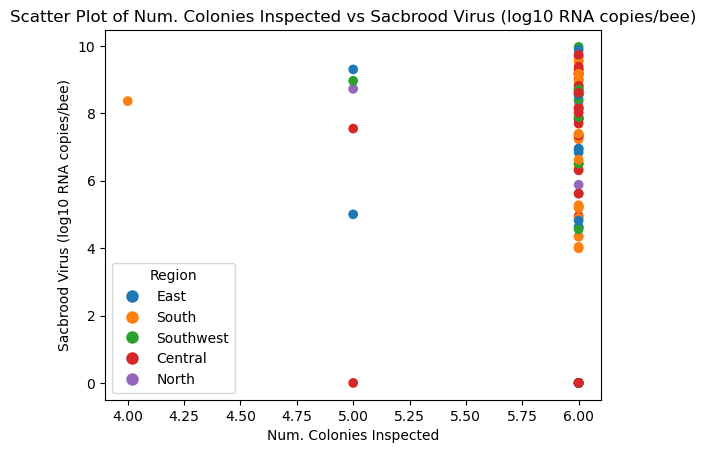

In [ ]:
## Correlation between Number of colonies inspected and the Sacbrood Virus - Scatter Plot

apiary['Region'].unique()
apiary.groupby('Region').size()
# Create mapping between values and colors
labels = apiary["Region"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Plot
plt.scatter(apiary["Num. Colonies Inspected"], apiary['Sacbrood Virus (log10 RNA copies/bee)'], 
            color=apiary["Region"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add labels and legend
plt.xlabel('Num. Colonies Inspected')
plt.ylabel('Sacbrood Virus (log10 RNA copies/bee)')
plt.title('Scatter Plot of Num. Colonies Inspected vs Sacbrood Virus (log10 RNA copies/bee)')
plt.legend(handles=handles, title='Region')
plt.show()



### Visualization for the correlation between the presence of three different viruses across regions - 3D Scatter Plot
#### In this visualization I decided to plot a highlighted new observation in red. 

<module 'matplotlib.pyplot' from '/opt/miniconda3/envs/dsi_participant2/lib/python3.9/site-packages/matplotlib/pyplot.py'>

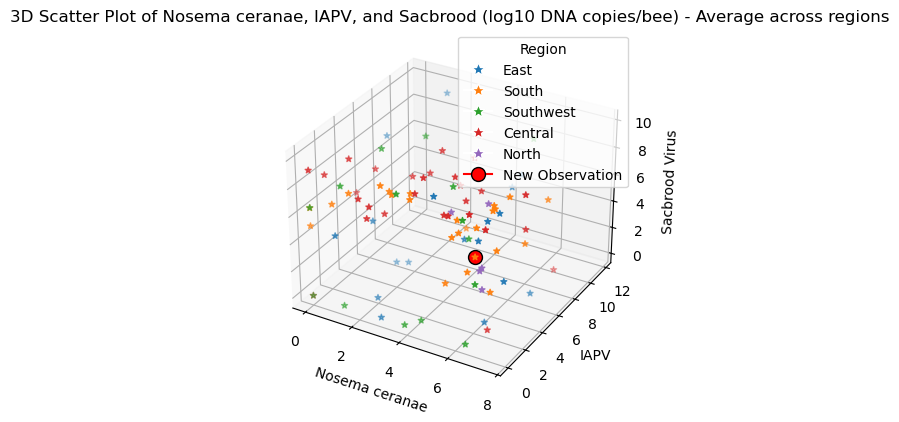

In [ ]:

### Correlation between three different viruses present across regions - 3D Scatter Plot

# Create mapping between values and colors
labels = apiary['Region'].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data with color corresponding to regions
sc = ax.scatter3D(apiary['Nosema ceranae (log10 DNA copies/bee) - Average'], apiary['Israeli Acute Paralysis Virus (log10 RNA copies/bee) - Average'], apiary['Sacbrood Virus (log10 RNA copies/bee)'], 
                  c=apiary['Region'].map(color_map), marker='*')

# Define the new observation
new_observation = {'Nosema ceranae (log10 DNA copies/bee) - Average': 6.772, 'Israeli Acute Paralysis Virus (log10 RNA copies/bee) - Average': 0.000, 'Sacbrood Virus (log10 RNA copies/bee)': 6.513 }

# Plot the new observation
ax.scatter3D(new_observation['Nosema ceranae (log10 DNA copies/bee) - Average'], new_observation['Israeli Acute Paralysis Virus (log10 RNA copies/bee) - Average'], 
             new_observation['Sacbrood Virus (log10 RNA copies/bee)'], color='red', edgecolor='black', 
             s=100, marker='o', label='New Observation')

# Add axis labels
ax.set_xlabel('Nosema ceranae')
ax.set_ylabel('IAPV') ## IAPV is the acronym for Israeli Acute Paralysis Virus
ax.set_zlabel('Sacbrood Virus')
ax.set_title('3D Scatter Plot of Nosema ceranae, IAPV, and Sacbrood (log10 DNA copies/bee) - Average across regions')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='*', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add custom legend for new observation
handles.append(plt.Line2D([0], [0], marker='o', color='red', label='New Observation', 
                          markersize=10, markeredgecolor='black'))

# Add legend
plt.legend(handles=handles, title='Region')

# Show plot
plt